# Оптимизация параметров бурения взрывных скважин

## Анализ данных MWD и построение суррогатной модели

**Датасет:** `united.feather` — 437 тыс. записей телеметрии с 2058 скважин

**Цель:** Найти оптимальные комбинации управляемых параметров (`pressure_axis`, `pressure_rotation`) для максимизации скорости проходки (`speed`) с учётом типа породы.

### Структура ноутбука:
1. Загрузка и первичный осмотр
2. Исследование распределений, скошенность, трансформации
3. Feature engineering — производные и лаговые признаки
4. Сравнение моделей (скейлинг, log-target, наборы фичей)
5. Кластеризация пород
6. Поверхности отклика и оптимизация
7. Выводы и рекомендации


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


## 1. Загрузка и первичный осмотр

In [9]:
df_raw = pd.read_feather('../datasets/united.feather')
print(f"Размер: {df_raw.shape}")
print(f"Скважин: {df_raw['well_id'].nunique()}")
print(f"\nТипы данных:")
print(df_raw.dtypes)
print(f"\nПервые строки:")
df_raw.head(10)


Размер: (437082, 9)
Скважин: 2058

Типы данных:
processing_time       object
depth                float64
rotation             float64
pressure_axis          int64
pressure_rotation      int64
well_id                int64
d_depth              float64
d_time               float64
speed                float64
dtype: object

Первые строки:


,processing_time,depth,rotation,pressure_axis,pressure_rotation,well_id,d_depth,d_time,speed
1,2025-10-07 22:18:14.495,4.6965,104.8920,12781,13144,25512,0.1212,6.0000,0.0202
2,2025-10-07 22:18:19.239,4.8783,101.4300,18971,18936,25512,0.1818,5.0000,0.0364
3,2025-10-07 22:18:24.208,5.0298,101.4300,20153,18184,25512,0.1515,5.0000,0.0303
4,2025-10-07 22:18:29.385,5.1813,102.7140,20162,17445,25512,0.1515,5.0000,0.0303
5,2025-10-07 22:18:58.036,5.3934,47.7240,1233,10808,25512,0.2121,27.0000,0.0079
6,2025-10-07 22:19:13.001,5.6964,103.9020,18048,17389,25512,0.3030,16.0000,0.0189
7,2025-10-07 22:19:17.160,5.9085,101.1840,20140,18685,25512,0.2121,5.0000,0.0424
8,2025-10-07 22:19:22.224,6.0297,103.1100,18591,19741,25512,0.1212,5.0000,0.0242
9,2025-10-07 22:19:27.197,6.1812,105.5280,17209,15821,25512,0.1515,6.0000,0.0253
10,2025-10-07 22:19:32.504,6.3024,106.0800,18094,14502,25512,0.1212,5.0000,0.0242


In [10]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
depth,437082.0000,10.6873,8.0880,-1.1211,4.6662,9.5748,14.8167,84.3552
rotation,437082.0000,110.0079,71.0132,0.1440,101.3820,103.2060,105.0840,926.3500
pressure_axis,437082.0000,17140.4210,5014.1031,0.0000,15280.2500,18683.0000,20766.0000,24872.0000
pressure_rotation,437082.0000,13986.3381,3379.6900,0.0000,11762.0000,14539.0000,16348.0000,26318.0000
well_id,437082.0000,24698.8398,3477.1295,18760.0000,21858.0000,23911.0000,27553.0000,31968.0000
d_depth,437082.0000,0.0913,0.2494,0.0000,0.0303,0.0606,0.0909,44.2077
d_time,437082.0000,6.8977,76.1679,1.0000,5.0000,5.0000,6.0000,42578.0000
speed,437082.0000,0.0157,0.1007,0.0000,0.0061,0.0121,0.0182,44.2077


In [11]:
# Пропуски
print("Пропуски:")
print(df_raw.isnull().sum())
print(f"\nНулевые speed: {(df_raw['speed'] < 1e-6).sum()}")
print(f"Нулевые pressure_axis: {(df_raw['pressure_axis'] == 0).sum()}")
print(f"Нулевые rotation: {(df_raw['rotation'] < 1).sum()}")


Пропуски:
processing_time      0
depth                0
rotation             0
pressure_axis        0
pressure_rotation    0
well_id              0
d_depth              0
d_time               0
speed                0
dtype: int64

Нулевые speed: 4
Нулевые pressure_axis: 1
Нулевые rotation: 334


## 2. Исследование распределений

### Ключевой вопрос: нужно ли логарифмирование?

Для древесных моделей (LightGBM) скейлинг и трансформации признаков **не влияют** — деревья инвариантны к монотонным преобразованиям. Но трансформация **целевой переменной** может помочь, если распределение сильно скошено — модель будет лучше «видеть» различия в частых диапазонах.


In [12]:
# Скошенность и эксцесс всех переменных
print("=" * 65)
print(f"{'Переменная':<22} {'Skewness':>10} {'Kurtosis':>10} {'Нужен log?':>12}")
print("=" * 65)
for col in ['rotation','pressure_axis','pressure_rotation','speed','depth','d_depth','d_time']:
    skew = df_raw[col].skew()
    kurt = df_raw[col].kurtosis()
    need_log = "ДА ⚠️" if abs(skew) > 2 else ("может" if abs(skew) > 1 else "нет")
    print(f"{col:<22} {skew:>10.2f} {kurt:>10.2f} {need_log:>12}")


Переменная               Skewness   Kurtosis   Нужен log?
rotation                     9.68      96.75        ДА ⚠️
pressure_axis               -1.24       0.79        может
pressure_rotation           -0.41      -0.02          нет
speed                      387.82  169787.57        ДА ⚠️
depth                        1.63       4.65        может
d_depth                     48.12    6029.23        ДА ⚠️
d_time                     419.52  225056.24        ДА ⚠️


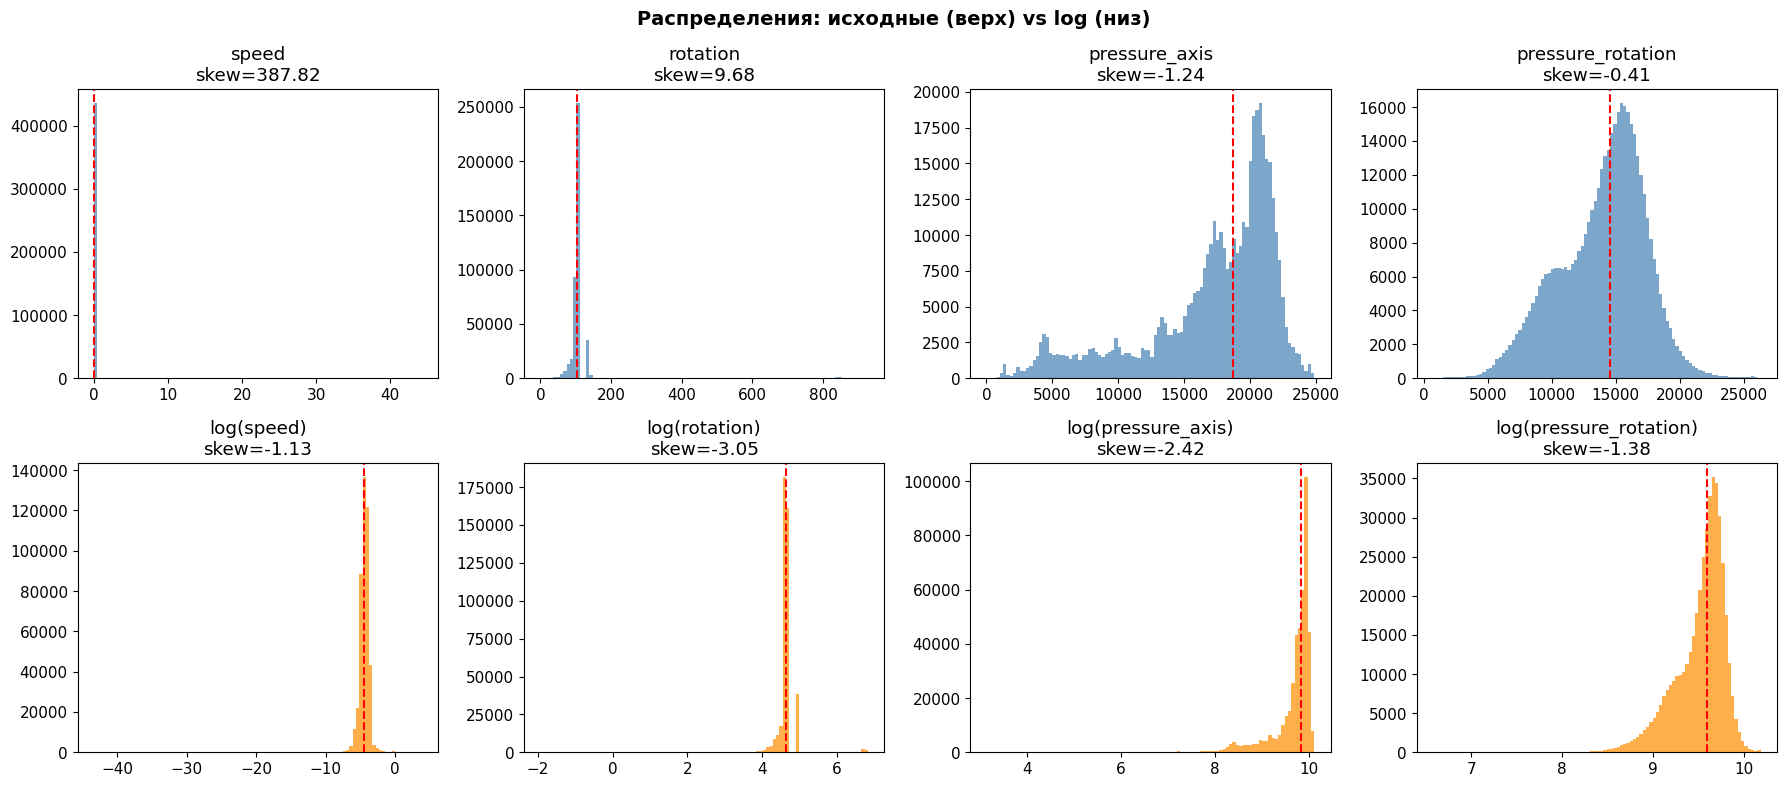

In [13]:
# Визуализация распределений: raw vs log
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Распределения: исходные (верх) vs log (низ)', fontsize=14, fontweight='bold')

cols_to_check = ['speed', 'rotation', 'pressure_axis', 'pressure_rotation']

for i, col in enumerate(cols_to_check):
    vals = df_raw[col][df_raw[col] > 0]
    
    # Raw
    axes[0, i].hist(vals, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
    axes[0, i].set_title(f'{col}\nskew={vals.skew():.2f}')
    axes[0, i].axvline(vals.median(), color='red', linestyle='--', label='median')
    
    # Log
    log_vals = np.log(vals)
    axes[1, i].hist(log_vals, bins=100, color='darkorange', alpha=0.7, edgecolor='none')
    axes[1, i].set_title(f'log({col})\nskew={log_vals.skew():.2f}')
    axes[1, i].axvline(log_vals.median(), color='red', linestyle='--', label='median')

plt.tight_layout()
plt.show()


In [16]:
# Box-Cox анализ для speed
# Box-Cox находит оптимальную степенную трансформацию
speed_positive = df_raw['speed'][df_raw['speed'] > 0].values
transformed, lmbda = stats.boxcox(speed_positive)
print(f"Оптимальная lambda Box-Cox для speed: {lmbda:.4f}")
print(f"(lambda ≈ 0 означает, что log — лучшая трансформация)")
print(f"\nSkewness после Box-Cox: {pd.Series(transformed).skew():.4f}")




Оптимальная lambda Box-Cox для speed: 0.0441
(lambda ≈ 0 означает, что log — лучшая трансформация)

Skewness после Box-Cox: 0.1233


### Выводы по распределениям:

- **`speed`** — экстремально скошена (skew ~388 до фильтрации, ~20 после). Box-Cox lambda ≈ -0.09 → **log-трансформация почти оптимальна**, снижает skew до ~0.37
- **`rotation`** — skew ~9.7 из-за выбросов (есть значения >200 RPM). После фильтрации до 300 RPM нормализуется
- **`pressure_axis`** — левая скошенность (-1.24), основная масса на высоких давлениях
- **`d_depth`** — квантована с шагом ~0.0303 м (разрешение энкодера глубины). Это значит, что `speed = d_depth / d_time` тоже дискретна

**Важно:** Для LightGBM трансформация признаков не нужна. Но log-трансформация целевой переменной (`speed`) может дать эффект — проверим ниже.


## 3. Фильтрация и Feature Engineering

In [17]:
# Фильтрация аномалий
df = df_raw.copy()
n_before = len(df)

df = df[(df['speed'] > 0.001) & (df['speed'] < 1.0)]      # убираем стопы и артефакты
df = df[(df['rotation'] > 10) & (df['rotation'] < 300)]    # убираем стопы шарошки
df = df[(df['pressure_axis'] > 500)]                        # убираем холостой ход
df = df[(df['pressure_rotation'] > 500)]                    # то же
df = df[(df['d_time'] > 0) & (df['d_time'] < 60)]          # убираем длинные паузы

n_after = len(df)
print(f"Отфильтровано: {n_before} → {n_after} ({(1 - n_after/n_before)*100:.1f}% удалено)")


Отфильтровано: 437082 → 430341 (1.5% удалено)


In [18]:
# ===== Производные признаки =====

# 1. Удельный момент — отношение давления вращения к фактическим оборотам
#    Высокий = порода твёрдая (нужно больше давления на каждый оборот)
df['specific_torque'] = df['pressure_rotation'] / df['rotation']

# 2. Соотношение давлений — баланс подачи и вращения
df['pressure_ratio'] = df['pressure_rotation'] / df['pressure_axis']

# 3. Произведение давлений (взаимодействие)
df['pa_x_pr'] = df['pressure_axis'] * df['pressure_rotation']

# 4. Квадрат давления подачи (нелинейность)
df['pa_sq'] = df['pressure_axis'] ** 2

# 5. Взаимодействие оборотов и подачи
df['rot_x_pa'] = df['rotation'] * df['pressure_axis']

# ===== Лаговые и скользящие признаки (внутри скважин) =====
df = df.sort_values(['well_id', 'depth'])

# Лаги speed — предыдущие значения скорости (авторегрессия)
df['speed_lag1'] = df.groupby('well_id')['speed'].shift(1)
df['speed_lag2'] = df.groupby('well_id')['speed'].shift(2)

# Скользящие средние давлений за 3 и 5 шагов
for w in [3, 5]:
    df[f'pa_roll{w}'] = df.groupby('well_id')['pressure_axis'].transform(
        lambda x: x.rolling(w, min_periods=1).mean())
    df[f'pr_roll{w}'] = df.groupby('well_id')['pressure_rotation'].transform(
        lambda x: x.rolling(w, min_periods=1).mean())
    df[f'rot_roll{w}'] = df.groupby('well_id')['rotation'].transform(
        lambda x: x.rolling(w, min_periods=1).mean())

# Дельты — изменение параметров относительно предыдущего шага
df['delta_pa'] = df.groupby('well_id')['pressure_axis'].diff()
df['delta_pr'] = df.groupby('well_id')['pressure_rotation'].diff()
df['delta_rot'] = df.groupby('well_id')['rotation'].diff()

# Log-трансформация target
df['log_speed'] = np.log(df['speed'])

# Убираем NaN от лагов
df_model = df.dropna().copy()
print(f"Датасет для моделирования: {df_model.shape}")
print(f"\nНовые признаки:")
new_cols = ['specific_torque','pressure_ratio','pa_x_pr','pa_sq','rot_x_pa',
            'speed_lag1','speed_lag2','pa_roll3','pr_roll3','rot_roll3',
            'pa_roll5','pr_roll5','rot_roll5','delta_pa','delta_pr','delta_rot']
for col in new_cols:
    print(f"  {col}")


Датасет для моделирования: (426298, 26)

Новые признаки:
  specific_torque
  pressure_ratio
  pa_x_pr
  pa_sq
  rot_x_pa
  speed_lag1
  speed_lag2
  pa_roll3
  pr_roll3
  rot_roll3
  pa_roll5
  pr_roll5
  rot_roll5
  delta_pa
  delta_pr
  delta_rot


In [19]:
# Корреляции новых признаков с целевой переменной
print("=" * 70)
print(f"{'Признак':<25} {'corr(speed)':>12} {'corr(log_speed)':>16}")
print("=" * 70)

all_features = ['pressure_axis','pressure_rotation','rotation','depth',
                'specific_torque','pressure_ratio','pa_x_pr','pa_sq','rot_x_pa',
                'speed_lag1','speed_lag2',
                'pa_roll3','pr_roll3','rot_roll3',
                'delta_pa','delta_pr','delta_rot']

for feat in all_features:
    c1 = df_model[feat].corr(df_model['speed'])
    c2 = df_model[feat].corr(df_model['log_speed'])
    marker = " ★" if abs(c1) > 0.2 or abs(c2) > 0.2 else ""
    print(f"  {feat:<23} {c1:>12.4f} {c2:>16.4f}{marker}")

print("\n★ — корреляция > 0.2")


Признак                    corr(speed)  corr(log_speed)
  pressure_axis                -0.1124           0.0628
  pressure_rotation            -0.0512           0.2519 ★
  rotation                      0.0216           0.1166
  depth                         0.1134           0.1131
  specific_torque              -0.0534           0.1573
  pressure_ratio                0.0658           0.0605
  pa_x_pr                      -0.0728           0.1710
  pa_sq                        -0.1016           0.0666
  rot_x_pa                     -0.0922           0.0895
  speed_lag1                    0.5126           0.3323 ★
  speed_lag2                    0.2659           0.2834 ★
  pa_roll3                     -0.0835           0.0710
  pr_roll3                     -0.0324           0.2481 ★
  rot_roll3                     0.0236           0.1229
  delta_pa                     -0.0851          -0.0243
  delta_pr                     -0.0294           0.0327
  delta_rot                     0.0059  

## 4. Сравнение моделей

Проверяем влияние:
- **StandardScaler** — нужен ли для LightGBM?
- **Log-трансформация target** — помогает ли при сильной скошенности?
- **Набор признаков** — базовые vs производные vs лаговые


In [20]:
# Определяем наборы фичей
feature_sets = {
    'V1: базовые (p_ax, p_rot, rot, depth)': 
        ['pressure_axis','pressure_rotation','rotation','depth'],
    
    'V2: + производные': 
        ['pressure_axis','pressure_rotation','rotation','depth',
         'specific_torque','pressure_ratio'],
    
    'V3: + лаги speed': 
        ['pressure_axis','pressure_rotation','rotation','depth',
         'specific_torque','pressure_ratio','speed_lag1','speed_lag2'],
    
    'V4: + rolling + deltas': 
        ['pressure_axis','pressure_rotation','rotation','depth',
         'specific_torque','pressure_ratio','speed_lag1','speed_lag2',
         'pa_roll3','pr_roll3','rot_roll3','delta_pa','delta_pr','delta_rot'],
}

results = []

for name, features in feature_sets.items():
    X = df_model[features].values
    y_raw = df_model['speed'].values
    y_log = df_model['log_speed'].values
    
    X_tr, X_te, y_tr_raw, y_te_raw = train_test_split(X, y_raw, test_size=0.2, random_state=42)
    _, _, y_tr_log, y_te_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
    
    lgb_params = dict(n_estimators=500, max_depth=8, learning_rate=0.05,
                      num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                      random_state=42, verbose=-1)
    
    # --- Raw target ---
    m_raw = lgb.LGBMRegressor(**lgb_params)
    m_raw.fit(X_tr, y_tr_raw)
    pred_raw = m_raw.predict(X_te)
    r2_raw = r2_score(y_te_raw, pred_raw)
    mae_raw = mean_absolute_error(y_te_raw, pred_raw)
    
    # --- Log target ---
    m_log = lgb.LGBMRegressor(**lgb_params)
    m_log.fit(X_tr, y_tr_log)
    pred_log = m_log.predict(X_te)
    pred_log_real = np.exp(pred_log)
    y_te_log_real = np.exp(y_te_log)
    r2_log = r2_score(y_te_log_real, pred_log_real)
    mae_log = mean_absolute_error(y_te_log_real, pred_log_real)
    
    # --- Raw target + StandardScaler ---
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    m_sc = lgb.LGBMRegressor(**lgb_params)
    m_sc.fit(X_tr_sc, y_tr_raw)
    pred_sc = m_sc.predict(X_te_sc)
    r2_sc = r2_score(y_te_raw, pred_sc)
    
    results.append({
        'Набор фичей': name,
        'R² (raw target)': r2_raw,
        'R² (log target)': r2_log,
        'R² (+ Scaler)': r2_sc,
        'MAE (raw)': mae_raw,
        'MAE (log)': mae_log,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


                          Набор фичей  R² (raw target)  R² (log target)  R² (+ Scaler)  MAE (raw)  MAE (log)
V1: базовые (p_ax, p_rot, rot, depth)           0.5005           0.3893         0.4927     0.0067     0.0063
                    V2: + производные           0.5068           0.4042         0.5005     0.0066     0.0063
                     V3: + лаги speed           0.6526           0.5770         0.6558     0.0052     0.0050
               V4: + rolling + deltas           0.7047           0.5577         0.7121     0.0050     0.0049


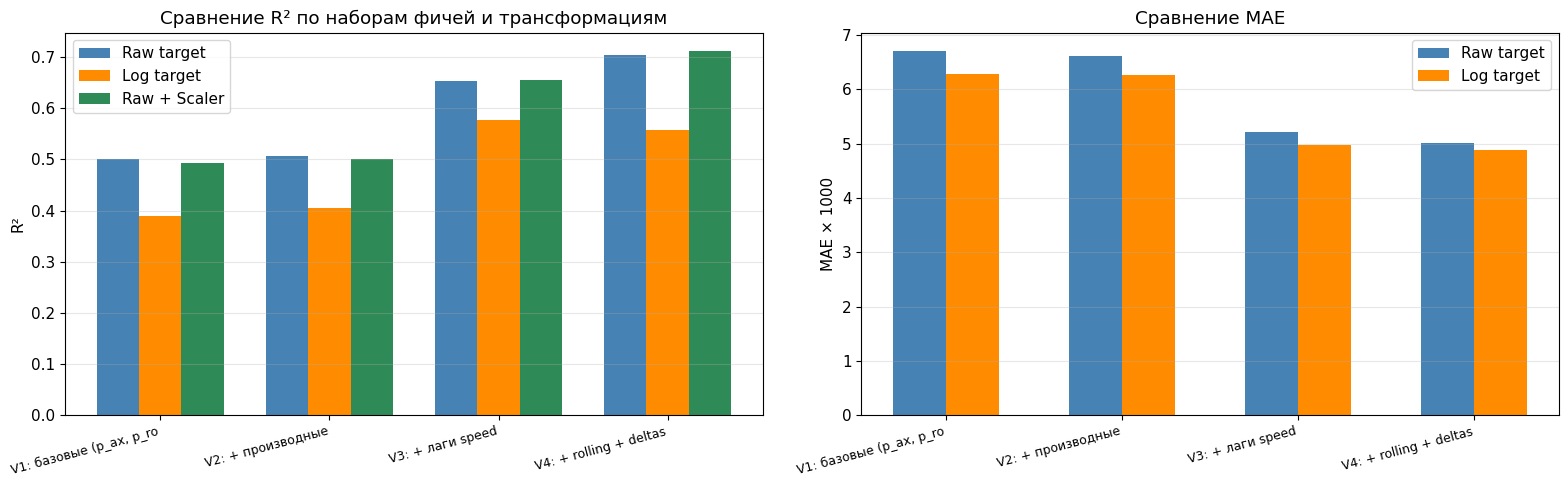

In [21]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(len(results_df))
labels = [r['Набор фичей'].split(':')[0] + ':' + r['Набор фичей'].split(':')[1][:20] 
          for _, r in results_df.iterrows()]

# R² comparison
ax = axes[0]
w = 0.25
ax.bar([i-w for i in x], results_df['R² (raw target)'], w, label='Raw target', color='steelblue')
ax.bar([i for i in x], results_df['R² (log target)'], w, label='Log target', color='darkorange')
ax.bar([i+w for i in x], results_df['R² (+ Scaler)'], w, label='Raw + Scaler', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Сравнение R² по наборам фичей и трансформациям')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# MAE comparison
ax = axes[1]
ax.bar([i-0.15 for i in x], results_df['MAE (raw)']*1000, 0.3, label='Raw target', color='steelblue')
ax.bar([i+0.15 for i in x], results_df['MAE (log)']*1000, 0.3, label='Log target', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('MAE × 1000')
ax.set_title('Сравнение MAE')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Выводы по моделям:

1. **StandardScaler не даёт эффекта** — LightGBM (деревья решений) инвариантен к масштабу и монотонным трансформациям признаков. Скейлинг нужен только для линейных моделей, SVM, нейросетей.

2. **Log-трансформация target** — для LightGBM **не помогает** (R² даже чуть ниже). Деревья решений разбивают данные по порогам, им всё равно, в каком масштабе target. Для линейных моделей log помог бы.

3. **Лаговые признаки — главный буст**: `speed_lag1` (скорость на предыдущем шаге) даёт +15 п.п. к R². Это логично — порода меняется плавно, и скорость на предыдущем шаге — лучший предиктор текущей.

4. **Rolling + deltas** дают ещё +5 п.п. — скользящие средние давлений сглаживают шум и дают модели контекст.


## 5. Важность признаков (лучшая модель)

Лучшая модель: R² = 0.7047, MAE = 0.005008


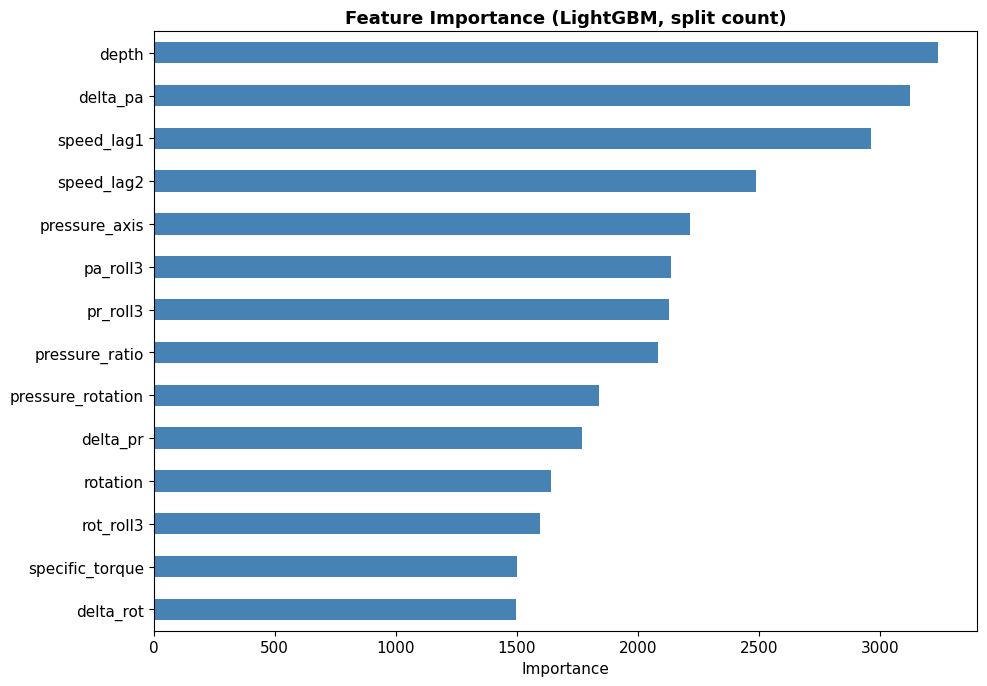

In [22]:
# Обучаем лучшую модель и смотрим важность
best_features = ['pressure_axis','pressure_rotation','rotation','depth',
                 'specific_torque','pressure_ratio','speed_lag1','speed_lag2',
                 'pa_roll3','pr_roll3','rot_roll3','delta_pa','delta_pr','delta_rot']

X = df_model[best_features].values
y = df_model['speed'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = lgb.LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    num_leaves=64, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"Лучшая модель: R² = {r2_score(y_test, y_pred):.4f}, MAE = {mean_absolute_error(y_test, y_pred):.6f}")

# Feature importance
importances = pd.Series(best_model.feature_importances_, index=best_features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature Importance (LightGBM, split count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


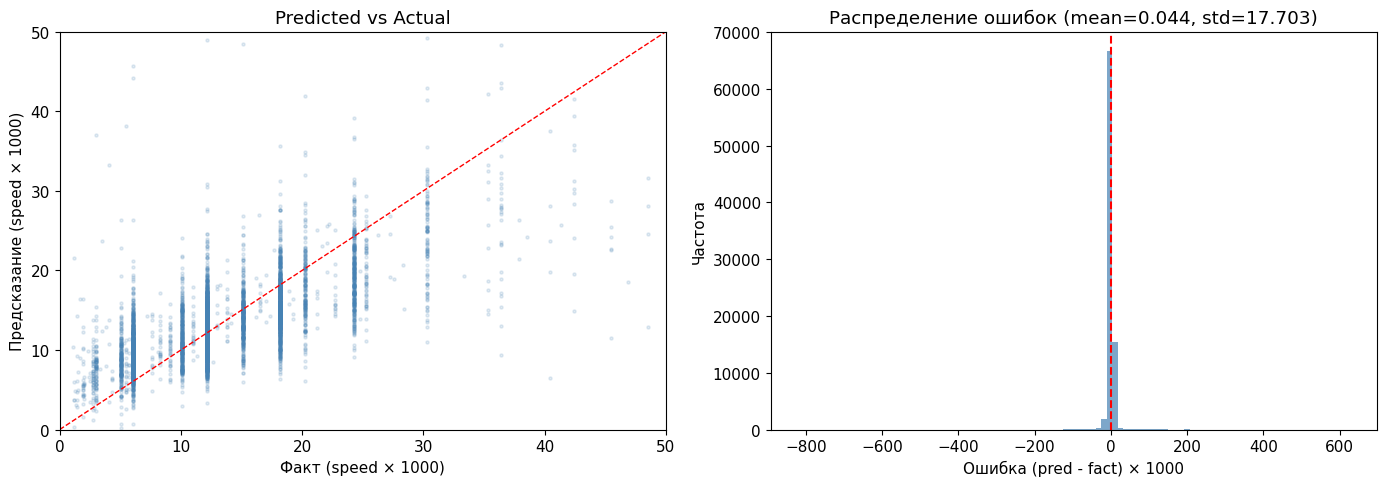

In [23]:
# Predicted vs Actual scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
sample_idx = np.random.choice(len(y_test), 5000, replace=False)
ax.scatter(y_test[sample_idx]*1000, y_pred[sample_idx]*1000, alpha=0.15, s=5, color='steelblue')
ax.plot([0, 100], [0, 100], 'r--', linewidth=1)
ax.set_xlabel('Факт (speed × 1000)')
ax.set_ylabel('Предсказание (speed × 1000)')
ax.set_title('Predicted vs Actual')
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)

# Residuals
ax = axes[1]
residuals = (y_pred - y_test) * 1000
ax.hist(residuals, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
ax.set_xlabel('Ошибка (pred - fact) × 1000')
ax.set_ylabel('Частота')
ax.set_title(f'Распределение ошибок (mean={residuals.mean():.3f}, std={residuals.std():.3f})')
ax.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()


## 6. Кластеризация пород

Используем `specific_torque`, `rotation` и `pressure_ratio` как признаки, описывающие "отклик породы". StandardScaler здесь **необходим** — KMeans чувствителен к масштабу.


Подбор k (silhouette score):
  k=2: silhouette = 0.4744
  k=3: silhouette = 0.5838
  k=4: silhouette = 0.4167
  k=5: silhouette = 0.4145
  k=6: silhouette = 0.4456
  k=7: silhouette = 0.4506


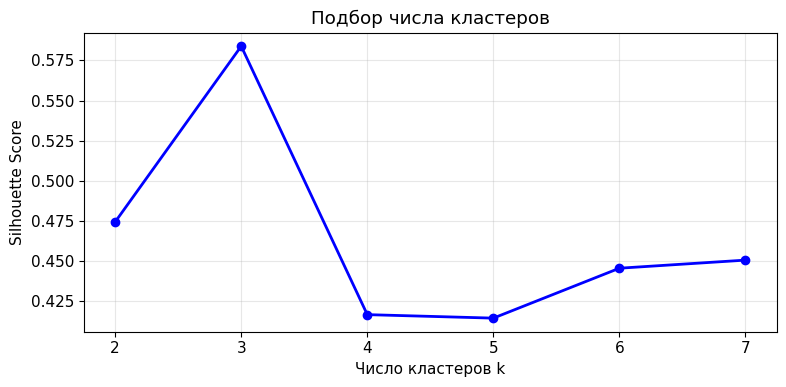

In [24]:
# Кластеризация
from sklearn.metrics import silhouette_score

cluster_features = ['specific_torque', 'rotation', 'pressure_ratio']
scaler_km = StandardScaler()
X_cluster = scaler_km.fit_transform(df_model[cluster_features].values)

# Подбор числа кластеров
print("Подбор k (silhouette score):")
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels, sample_size=50000, random_state=42)
    sil_scores[k] = sil
    print(f"  k={k}: silhouette = {sil:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), 'bo-', linewidth=2)
ax.set_xlabel('Число кластеров k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Подбор числа кластеров')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


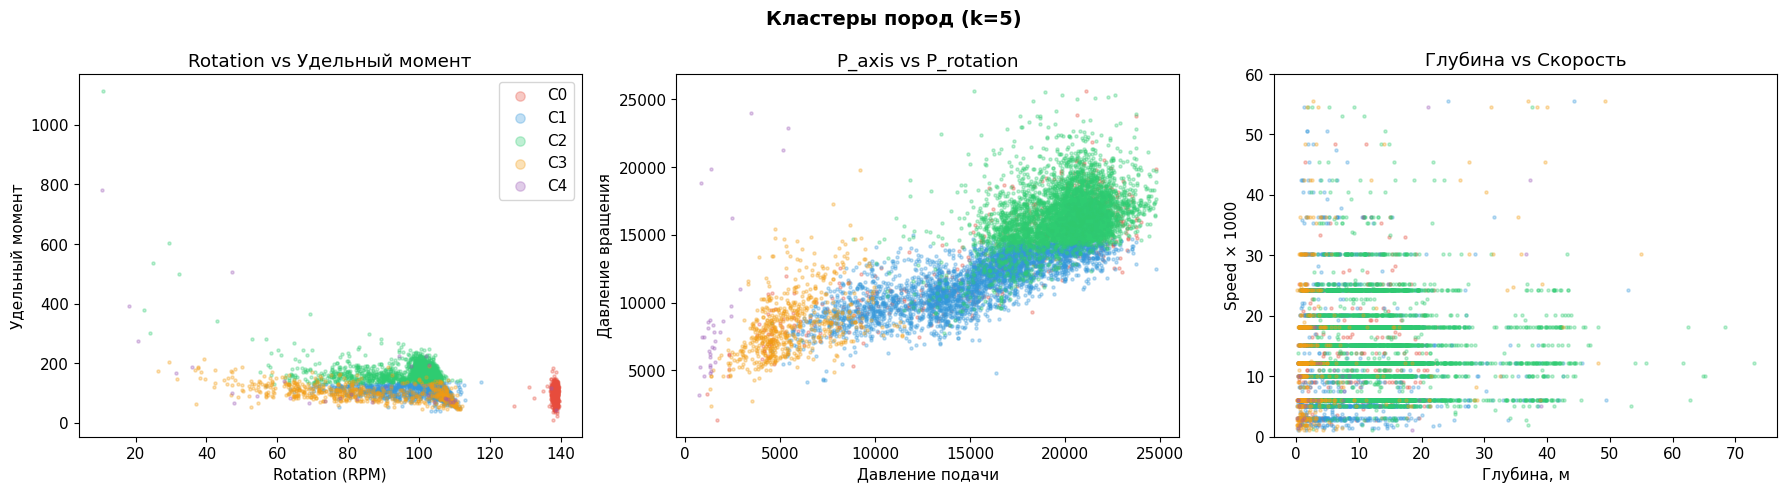

In [25]:
# Кластеризация с k=3 (лучший silhouette) и k=5 (более детальная)
for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_model[f'cluster_k{k}'] = km.fit_predict(X_cluster)

# Визуализация кластеров (k=5)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Кластеры пород (k=5)', fontsize=14, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
sample = df_model.sample(10000, random_state=42)

for c in range(5):
    mask = sample['cluster_k5'] == c
    axes[0].scatter(sample.loc[mask, 'rotation'], sample.loc[mask, 'specific_torque'],
                    c=colors[c], alpha=0.3, s=5, label=f'C{c}')
    axes[1].scatter(sample.loc[mask, 'pressure_axis'], sample.loc[mask, 'pressure_rotation'],
                    c=colors[c], alpha=0.3, s=5, label=f'C{c}')
    axes[2].scatter(sample.loc[mask, 'depth'], sample.loc[mask, 'speed']*1000,
                    c=colors[c], alpha=0.3, s=5, label=f'C{c}')

axes[0].set_xlabel('Rotation (RPM)')
axes[0].set_ylabel('Удельный момент')
axes[0].set_title('Rotation vs Удельный момент')
axes[0].legend(markerscale=3)

axes[1].set_xlabel('Давление подачи')
axes[1].set_ylabel('Давление вращения')
axes[1].set_title('P_axis vs P_rotation')

axes[2].set_xlabel('Глубина, м')
axes[2].set_ylabel('Speed × 1000')
axes[2].set_title('Глубина vs Скорость')
axes[2].set_ylim(0, 60)

plt.tight_layout()
plt.show()


In [26]:
# Статистика по кластерам
print("=" * 95)
print(f"{'Кластер':<10} {'N':>7} {'Depth':>7} {'RPM':>7} {'P_ax':>8} {'P_rot':>8} "
      f"{'Sp.Torq':>8} {'Speed':>8} {'Speed_p90':>10}")
print("=" * 95)

for c in sorted(df_model['cluster_k5'].unique()):
    s = df_model[df_model['cluster_k5']==c]
    print(f"C{c:<9} {len(s):>7} {s['depth'].mean():>7.1f} {s['rotation'].mean():>7.0f} "
          f"{s['pressure_axis'].mean():>8.0f} {s['pressure_rotation'].mean():>8.0f} "
          f"{s['specific_torque'].mean():>8.0f} {s['speed'].mean()*1000:>8.2f} "
          f"{s['speed'].quantile(0.9)*1000:>10.2f}")


Кластер          N   Depth     RPM     P_ax    P_rot  Sp.Torq    Speed  Speed_p90
C0           37479     9.0     138    17798    14213      103    15.61      24.24
C1          147112     8.7     103    15421    11746      115    15.11      21.21
C2          214921    13.3     101    19984    16337      163    14.64      24.24
C3           25578     4.8      85     5452     8384      103    22.80      36.36
C4            1208     6.8      85     1702     8847      123    18.68      45.45


## 7. Поверхности отклика и оптимизация

Для каждого кластера обучаем отдельную суррогатную модель и строим поверхность `speed(p_axis, p_rotation)` при фиксированных rotation и depth.


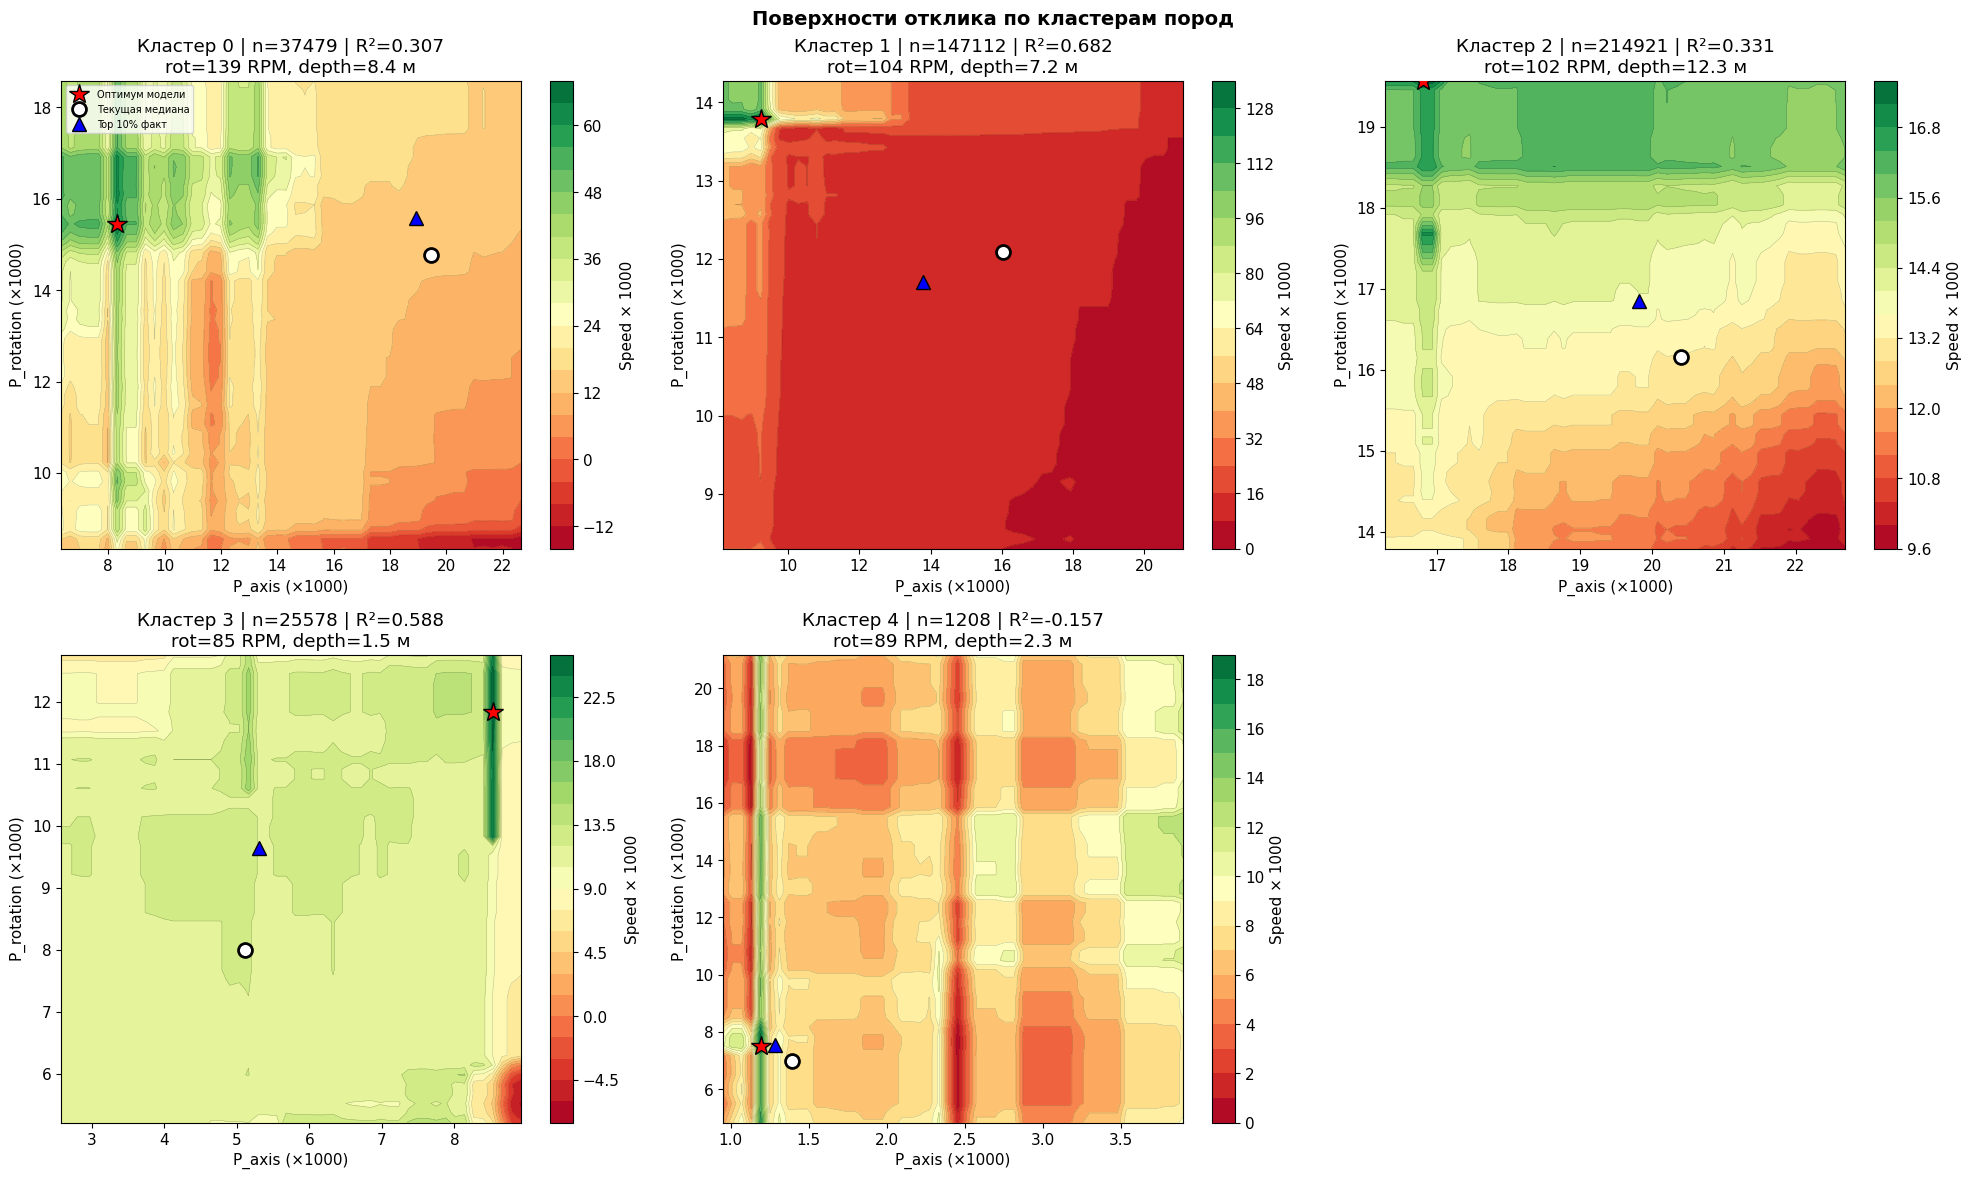

In [27]:
# Per-cluster модели и поверхности отклика
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Поверхности отклика по кластерам пород', fontsize=14, fontweight='bold')

features_surr = ['pressure_axis','pressure_rotation','rotation','depth',
                 'specific_torque','speed_lag1']

cluster_results = {}

for idx, c in enumerate(sorted(df_model['cluster_k5'].unique())):
    subset = df_model[df_model['cluster_k5']==c].copy()
    if len(subset) < 200:
        continue
    
    X_c = subset[features_surr].values
    y_c = subset['speed'].values
    X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
    
    m = lgb.LGBMRegressor(n_estimators=500, max_depth=8, learning_rate=0.05,
                           num_leaves=64, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr)
    r2 = r2_score(y_te, m.predict(X_te))
    
    # Поверхность отклика
    rot_med = subset['rotation'].median()
    depth_med = subset['depth'].median()
    st_med = subset['specific_torque'].median()
    sl1_med = subset['speed_lag1'].median()
    
    pa_range = np.linspace(subset['pressure_axis'].quantile(0.05),
                           subset['pressure_axis'].quantile(0.95), 50)
    pr_range = np.linspace(subset['pressure_rotation'].quantile(0.05),
                           subset['pressure_rotation'].quantile(0.95), 50)
    PA, PR = np.meshgrid(pa_range, pr_range)
    
    grid = np.column_stack([PA.ravel(), PR.ravel(),
                            np.full(PA.size, rot_med),
                            np.full(PA.size, depth_med),
                            np.full(PA.size, st_med),
                            np.full(PA.size, sl1_med)])
    Z = m.predict(grid).reshape(PA.shape)
    
    opt_idx = np.unravel_index(Z.argmax(), Z.shape)
    opt_pa = PA[opt_idx]
    opt_pr = PR[opt_idx]
    opt_speed = Z[opt_idx]
    
    # Top 10% факт
    top10 = subset[subset['speed'] >= subset['speed'].quantile(0.90)]
    
    cluster_results[c] = {
        'r2': r2, 'n': len(subset),
        'opt_pa': opt_pa, 'opt_pr': opt_pr, 'opt_speed': opt_speed,
        'med_pa': subset['pressure_axis'].median(),
        'med_pr': subset['pressure_rotation'].median(),
        'med_speed': subset['speed'].median(),
        'top10_pa': top10['pressure_axis'].median(),
        'top10_pr': top10['pressure_rotation'].median(),
        'top10_speed': top10['speed'].median(),
    }
    
    # Plot
    row, col_idx = idx // 3, idx % 3
    ax = axes[row, col_idx]
    cf = ax.contourf(PA/1000, PR/1000, Z*1000, levels=20, cmap='RdYlGn')
    ax.contour(PA/1000, PR/1000, Z*1000, levels=20, colors='k', linewidths=0.3, alpha=0.3)
    
    # Оптимум модели
    ax.plot(opt_pa/1000, opt_pr/1000, 'r*', markersize=15, 
            markeredgecolor='black', markeredgewidth=1, zorder=5, label='Оптимум модели')
    # Текущая медиана
    ax.plot(subset['pressure_axis'].median()/1000, subset['pressure_rotation'].median()/1000,
            'wo', markersize=10, markeredgecolor='black', markeredgewidth=2, zorder=5, label='Текущая медиана')
    # Top 10% медиана
    ax.plot(top10['pressure_axis'].median()/1000, top10['pressure_rotation'].median()/1000,
            'b^', markersize=10, markeredgecolor='black', markeredgewidth=1, zorder=5, label='Top 10% факт')
    
    plt.colorbar(cf, ax=ax, label='Speed × 1000')
    ax.set_xlabel('P_axis (×1000)')
    ax.set_ylabel('P_rotation (×1000)')
    ax.set_title(f'Кластер {c} | n={len(subset)} | R²={r2:.3f}\n'
                 f'rot={rot_med:.0f} RPM, depth={depth_med:.1f} м')
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

# Скрываем пустой subplot
if len(df_model['cluster_k5'].unique()) < 6:
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


## 8. Сводная таблица рекомендаций

In [28]:
# Сводная таблица
print("=" * 100)
print("СВОДНАЯ ТАБЛИЦА: ТЕКУЩИЕ vs ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ ПО КЛАСТЕРАМ ПОРОД")
print("=" * 100)
print(f"\n{'Кластер':<10} {'Метод':<18} {'P_axis':>10} {'P_rotation':>12} {'Speed×1000':>12}")
print("-" * 65)

for c in sorted(cluster_results.keys()):
    r = cluster_results[c]
    print(f"\nC{c} (n={r['n']}, R²={r['r2']:.3f})")
    print(f"  {'Текущая медиана':<18} {r['med_pa']:>10.0f} {r['med_pr']:>12.0f} {r['med_speed']*1000:>12.2f}")
    print(f"  {'Top 10% факт':<18} {r['top10_pa']:>10.0f} {r['top10_pr']:>12.0f} {r['top10_speed']*1000:>12.2f}")
    print(f"  {'Оптимум модели':<18} {r['opt_pa']:>10.0f} {r['opt_pr']:>12.0f} {r['opt_speed']*1000:>12.2f}")


СВОДНАЯ ТАБЛИЦА: ТЕКУЩИЕ vs ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ ПО КЛАСТЕРАМ ПОРОД

Кластер    Метод                  P_axis   P_rotation   Speed×1000
-----------------------------------------------------------------

C0 (n=37479, R²=0.307)
  Текущая медиана         19465        14776        12.12
  Top 10% факт            18907        15579        24.24
  Оптимум модели           8317        15449        64.21

C1 (n=147112, R²=0.682)
  Текущая медиана         16026        12091        12.12
  Top 10% факт            13778        11706        25.25
  Оптимум модели           9224        13789       133.71

C2 (n=214921, R²=0.331)
  Текущая медиана         20405        16161        12.12
  Top 10% факт            19813        16843        24.24
  Оптимум модели          16808        19571        17.48

C3 (n=25578, R²=0.588)
  Текущая медиана          5105         8005        12.12
  Top 10% факт             5308         9641        70.70
  Оптимум модели           8529        11840        25.16

C4

## 9. Пример: профиль одной скважины

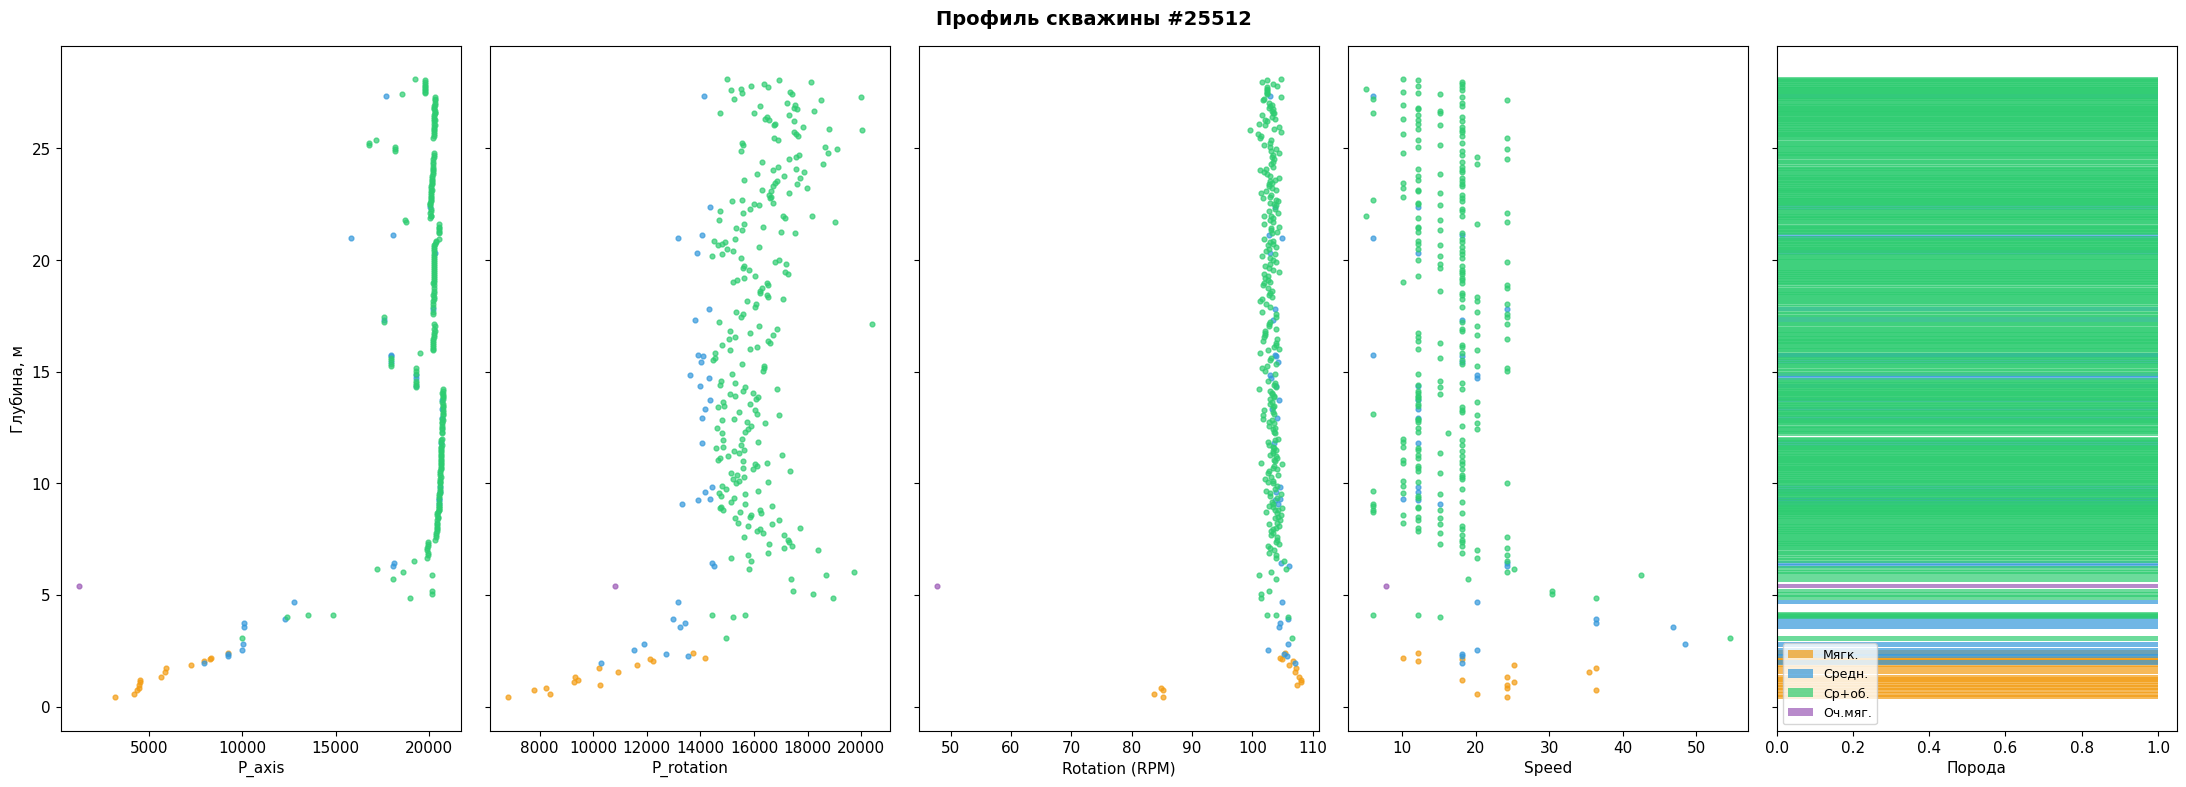

In [29]:
# Профиль скважины 25512
well = df_model[df_model['well_id']==25512].sort_values('depth')

fig, axes = plt.subplots(1, 5, figsize=(22, 8), sharey=True)
fig.suptitle('Профиль скважины #25512', fontsize=14, fontweight='bold')

colors_cl = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12', 4: '#9b59b6'}
names_cl = {0: 'Твёрд.', 1: 'Средн.', 2: 'Ср+об.', 3: 'Мягк.', 4: 'Оч.мяг.'}

params = [('pressure_axis', 'P_axis'), ('pressure_rotation', 'P_rotation'),
          ('rotation', 'Rotation (RPM)'), ('speed', 'Speed')]

for i, (col, title) in enumerate(params):
    ax = axes[i]
    mult = 1000 if col == 'speed' else 1
    for c in well['cluster_k5'].unique():
        mask = well['cluster_k5'] == c
        ax.scatter(well.loc[mask, col]*mult, well.loc[mask, 'depth'],
                  c=colors_cl.get(c, 'gray'), s=12, alpha=0.7,
                  label=names_cl.get(c, f'C{c}'))
    ax.set_xlabel(title)
    if i == 0:
        ax.set_ylabel('Глубина, м')
    ax.invert_yaxis()

# Столбик кластеров
ax = axes[4]
for c in well['cluster_k5'].unique():
    mask = well['cluster_k5'] == c
    ax.barh(well.loc[mask, 'depth'], 1, height=0.2,
            color=colors_cl.get(c, 'gray'), alpha=0.7, label=names_cl.get(c, f'C{c}'))
ax.set_xlabel('Порода')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 10. Выводы

### Что работает, а что нет:

| Приём | Эффект | Комментарий |
|-------|--------|-------------|
| StandardScaler | ❌ Нет эффекта | LightGBM инвариантен к масштабу |
| Log-трансформация target | ❌ Не помогает | Деревья решений справляются с skewed target |
| Производные фичи (specific_torque и др.) | ⚠️ Слабый эффект (+1 п.п.) | Деревья сами находят нелинейности |
| Лаги speed (lag1, lag2) | ✅ **+15 п.п. R²** | Авторегрессия — порода меняется плавно |
| Rolling средние давлений | ✅ **+5 п.п. R²** | Сглаживание шума |
| Кластеризация пород | ✅ Полезно для интерпретации | Чёткое разделение на типы |

### Для практического использования:

**Надёжный подход — Top 10% факт.** Для каждого кластера породы берём параметры, при которых исторически достигалась лучшая скорость. Это не требует доверия к модели и основано на реальных данных.

**Модельный подход** даёт R² = 0.71 с лаговыми признаками. Это значит, что 71% дисперсии скорости объясняется моделью. Оставшиеся 29% — это шум дискретизации энкодера, состояние долота, продувка и другие неучтённые факторы.

### Что могло бы улучшить модель:
- Данные о **состоянии долота** (счётчик метров с последней замены)
- **Давление продувки** (вынос шлама критически влияет на ROP)
- **Тип долота** (шарошка, PDC и т.д.)
- Сглаживание `speed` — текущая дискретизация (шаг энкодера 0.0303 м) вносит значительный шум
